# Big Mart Sales III: exploratory analysis

Sales of 1,559 products across 10 BigMart stores in 2013. The task is to predict
`Item_Outlet_Sales` for product-store pairs in the test file; the leaderboard
scores RMSE on the sales scale.

This notebook walks through the raw files, the data-quality issues and how they
are treated, and the structure that the modelling relies on. Every function
comes from `src/`, so the pipeline and the notebook cannot disagree.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src.data import load_raw, clean, FEATURE_COLUMNS
from src.features import build_features, MRP_BAND_EDGES
from src.structure import recover_units
sns.set_theme(style="whitegrid"); pd.set_option("display.width", 140)

train_raw, test_raw = load_raw()
print(train_raw.shape, test_raw.shape)
train_raw.head()

(8523, 12) (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 1. What is in the files

Each row is one product in one store. The test file has the same columns
without `Item_Outlet_Sales`.

In [2]:
print("train columns:", list(train_raw.columns))
print("test columns: ", list(test_raw.columns))
print()
print("products: train", train_raw.Item_Identifier.nunique(), "| test", test_raw.Item_Identifier.nunique(),
      "| test products unseen in train:", len(set(test_raw.Item_Identifier) - set(train_raw.Item_Identifier)))
print("stores:", sorted(train_raw.Outlet_Identifier.unique()))
both = pd.concat([train_raw, test_raw])
print("duplicate product-store pairs across train+test:", both.duplicated(["Item_Identifier", "Outlet_Identifier"]).sum())
print("rows per product (train):", train_raw.Item_Identifier.value_counts().describe()[["mean", "min", "max"]].round(2).to_dict())

train columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']
test columns:  ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

products: train 1559 | test 1543 | test products unseen in train: 0
stores: ['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027', 'OUT035', 'OUT045', 'OUT046', 'OUT049']
duplicate product-store pairs across train+test: 0
rows per product (train): {'mean': 5.47, 'min': 1.0, 'max': 10.0}


In [3]:
train_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDG33,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data-quality issues

Four things are wrong or odd in the raw data. None of them is an error to
delete; each is handled in `src/data.py` and the choice is tested by
validation (`reports/validation.md`, `reports/ablations.md`).

In [4]:
print("Missing values (%):")
print(both[FEATURE_COLUMNS].isna().mean().mul(100).round(1)[lambda s: s > 0])
print()
print("Outlet_Size missing in stores:", sorted(both.loc[both.Outlet_Size.isna(), "Outlet_Identifier"].unique()))
print("Item_Weight missing in stores:", sorted(both.loc[both.Item_Weight.isna(), "Outlet_Identifier"].unique()))
print("Item_Visibility == 0 share:", f"{(both.Item_Visibility == 0).mean():.1%}")
print()
print("Item_Fat_Content spellings:", both.Item_Fat_Content.value_counts().to_dict())

Missing values (%):
Item_Weight    17.2
Outlet_Size    28.3
dtype: float64

Outlet_Size missing in stores: ['OUT010', 'OUT017', 'OUT045']
Item_Weight missing in stores: ['OUT019', 'OUT027']
Item_Visibility == 0 share: 6.2%

Item_Fat_Content spellings: {'Low Fat': 8485, 'Regular': 4824, 'LF': 522, 'reg': 195, 'low fat': 178}


**Treatments:**

- *Fat content*: `LF`, `low fat` → `Low Fat`; `reg` → `Regular`. Products whose code starts `NC` (household, health & hygiene) get `Non-Edible`.
- *Missing weight*: a product weighs the same in every store, so the weight is borrowed from the stores that recorded it. Two stores (OUT019, OUT027) recorded no weights at all.
- *Zero visibility*: a product that sold was on a shelf, so 0 means "not recorded". It is replaced by the product's mean visibility elsewhere, and a `Visibility_Was_Zero` flag is kept.
- *Missing store size*: three whole stores have no size. They get the most common size of stores of the same type, plus an `Outlet_Size_Missing` flag.

Imputation statistics come from product and store columns only, never from sales.

In [5]:
train, test = build_features(*clean(train_raw, test_raw))
train[["Item_Identifier", "Item_Weight", "Item_Weight_Missing", "Item_Fat_Content", "Item_Visibility",
       "Visibility_Was_Zero", "Outlet_Size", "Outlet_Size_Missing", "Outlet_Age", "Item_Category", "MRP_Band"]].head(8)

,Item_Identifier,Item_Weight,Item_Weight_Missing,Item_Fat_Content,Item_Visibility,Visibility_Was_Zero,Outlet_Size,Outlet_Size_Missing,Outlet_Age,Item_Category,MRP_Band
0,FDA15,9.300,0,Low Fat,0.016047,0,Medium,0,14,Food,3
1,DRC01,5.920,0,Regular,0.019278,0,Medium,0,4,Drinks,0
2,FDN15,17.500,0,Low Fat,0.016760,0,Medium,0,14,Food,2
3,FDX07,19.200,0,Regular,0.022930,1,Small,1,15,Food,2
4,NCD19,8.930,0,Non-Edible,0.014670,1,High,0,26,Non-Consumable,0
5,FDP36,10.395,0,Regular,0.091294,1,Medium,0,4,Food,0
6,FDO10,13.650,0,Regular,0.012741,0,High,0,26,Food,0
7,FDP10,19.000,1,Low Fat,0.127470,0,Medium,0,28,Food,1


## 3. The target

{'count': 8523.0, 'mean': 2181.3, 'std': 1706.5, 'min': 33.3, '25%': 834.2, '50%': 1794.3, '75%': 3101.3, 'max': 13087.0} | skew 1.18


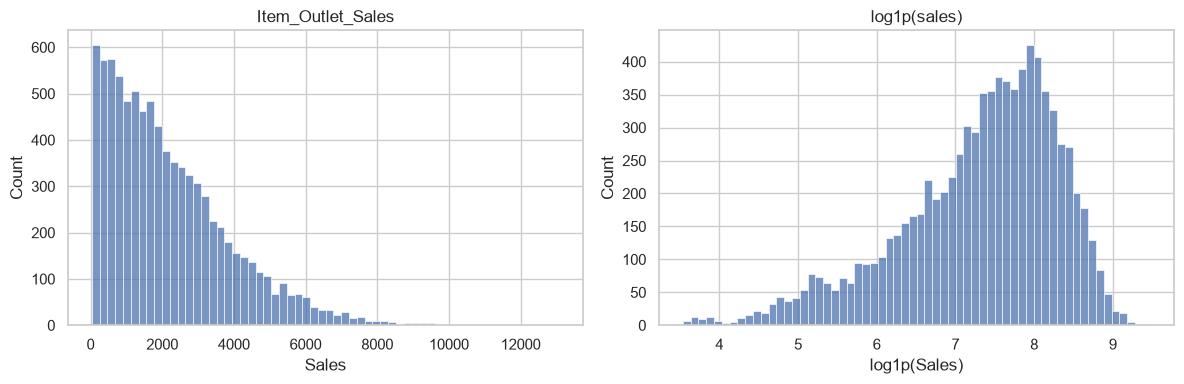

In [6]:
y = train["Item_Outlet_Sales"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, bins=60, ax=axes[0]); axes[0].set(title="Item_Outlet_Sales", xlabel="Sales")
sns.histplot(np.log1p(y), bins=60, ax=axes[1]); axes[1].set(title="log1p(sales)", xlabel="log1p(Sales)")
plt.tight_layout()
print(y.describe().round(1).to_dict(), "| skew", round(y.skew(), 2))

The target is right-skewed, which usually invites a log transform. The competition metric is RMSE on the raw scale, though, so any transform has to earn its place there (it does not; see `reports/ablations.md`).

## 4. Price sits in four bands

largest gaps between consecutive prices: [(np.float64(201.07), np.float64(205.0)), (np.float64(67.81), np.float64(71.34)), (np.float64(134.49), np.float64(137.82))]


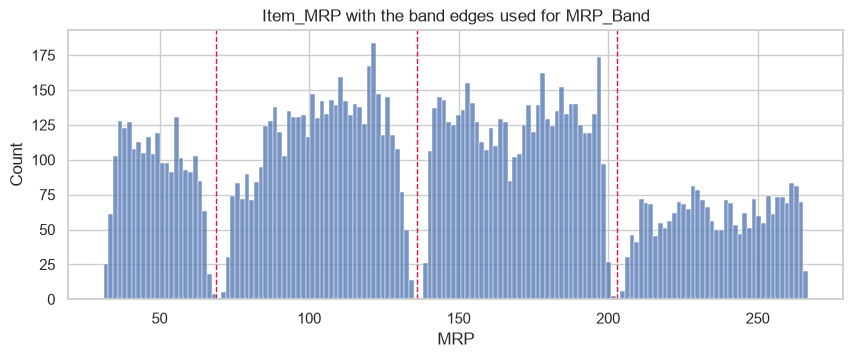

In [7]:
mrp = pd.concat([train.Item_MRP, test.Item_MRP])
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(mrp, bins=150, ax=ax)
for edge in MRP_BAND_EDGES[1:-1]: ax.axvline(edge, color="crimson", ls="--", lw=1)
ax.set(title="Item_MRP with the band edges used for MRP_Band", xlabel="MRP")
v = np.sort(mrp.to_numpy()); gaps = np.diff(v)
print("largest gaps between consecutive prices:", [(round(v[i], 2), round(v[i+1], 2)) for i in np.argsort(gaps)[::-1][:3]])

## 5. What drives sales: the store, through price

correlation with sales: {'Item_MRP': 0.568, 'Item_Visibility': -0.127, 'Item_Weight': 0.013, 'Outlet_Age': 0.049}


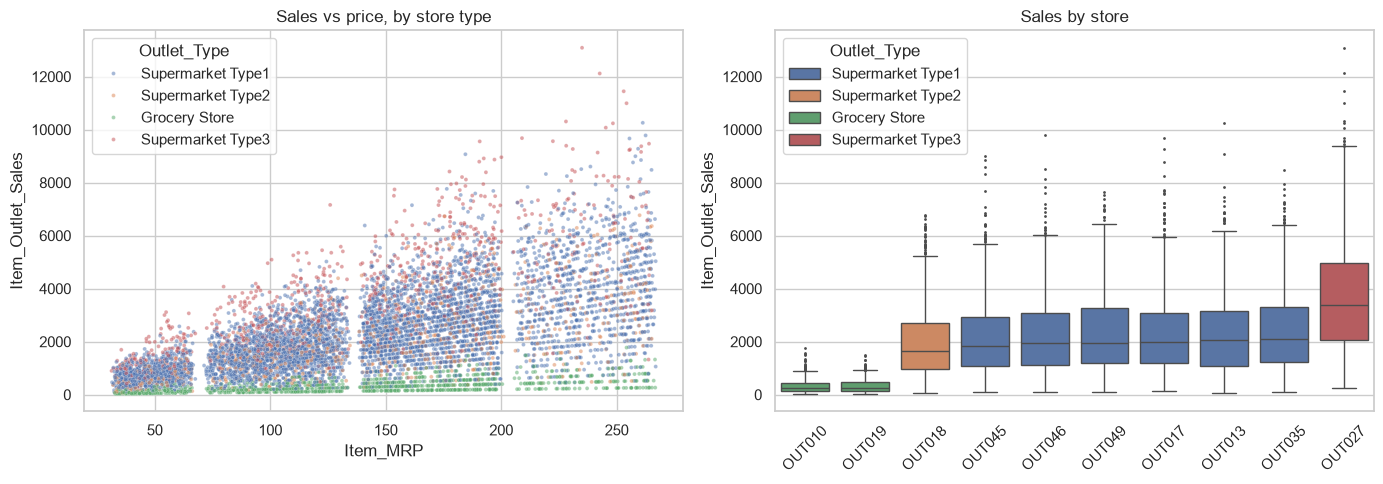

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=train, x="Item_MRP", y="Item_Outlet_Sales", hue="Outlet_Type", s=8, alpha=0.5, ax=axes[0])
axes[0].set(title="Sales vs price, by store type")
order = train.groupby("Outlet_Identifier").Item_Outlet_Sales.median().sort_values().index
sns.boxplot(data=train, x="Outlet_Identifier", y="Item_Outlet_Sales", hue="Outlet_Type", order=order, dodge=False, fliersize=1, ax=axes[1])
axes[1].tick_params(axis="x", rotation=45); axes[1].set(title="Sales by store", xlabel="")
plt.tight_layout()
print("correlation with sales:", train[["Item_MRP", "Item_Visibility", "Item_Weight", "Outlet_Age"]].corrwith(y).round(3).to_dict())

In [9]:
print("mean sales by product category (range):", train.groupby("Item_Type").Item_Outlet_Sales.mean().agg(["min", "max"]).round(0).to_dict())
print("mean sales by fat content:", train.groupby("Item_Fat_Content").Item_Outlet_Sales.mean().round(0).to_dict())
print("mean sales by store type:", train.groupby("Outlet_Type").Item_Outlet_Sales.mean().round(0).to_dict())

mean sales by product category (range): {'min': 1926.0, 'max': 2374.0}
mean sales by fat content: {'Low Fat': 2164.0, 'Non-Edible': 2143.0, 'Regular': 2225.0}
mean sales by store type: {'Grocery Store': 340.0, 'Supermarket Type1': 2316.0, 'Supermarket Type2': 1995.0, 'Supermarket Type3': 3694.0}


Price and store type dominate. Category and fat content barely move the mean.

## 6. The hidden structure: whole units × price

Every training sale splits exactly as `units × (Item_MRP + offset)`, with
`units` a whole number and `offset` a multiple of 0.1 between −2 and +2
(`src/structure.py`).

rows that split exactly: 100.0%
example: 443.4228 = 9 x (48.2692 + +1.0)
corr(units, MRP): 0.012 | corr(offset, MRP): -0.008
mean units by store type: {'Grocery Store': 2.4, 'Supermarket Type1': 16.3, 'Supermarket Type2': 13.9, 'Supermarket Type3': 26.6}
units relative to store mean, by category (range): {'min': 0.969, 'max': 1.074}


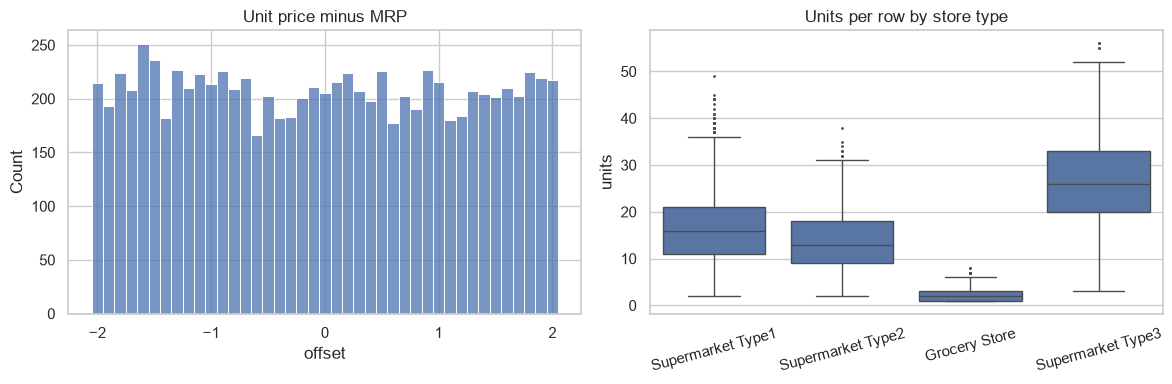

In [10]:
units, offset = recover_units(train.Item_Outlet_Sales, train.Item_MRP)
found = ~np.isnan(units)
print(f"rows that split exactly: {found.mean():.1%}")
example = train.iloc[1]
print(f"example: {example.Item_Outlet_Sales} = {units[1]:.0f} x ({example.Item_MRP} + {offset[1]:+.1f})")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(offset[found], binwidth=0.1, binrange=(-2.05, 2.05), ax=axes[0]); axes[0].set(title="Unit price minus MRP", xlabel="offset")
sns.boxplot(x=train.Outlet_Type, y=units, fliersize=1, ax=axes[1]); axes[1].set(title="Units per row by store type", xlabel="", ylabel="units")
axes[1].tick_params(axis="x", rotation=15); plt.tight_layout()
df = train[found].assign(units=units[found], offset=offset[found])
df["relative"] = df.units / df.groupby("Outlet_Identifier").units.transform("mean")
print("corr(units, MRP):", round(np.corrcoef(df.units, df.Item_MRP)[0, 1], 3), "| corr(offset, MRP):", round(np.corrcoef(df.offset, df.Item_MRP)[0, 1], 3))
print("mean units by store type:", df.groupby("Outlet_Type").units.mean().round(1).to_dict())
print("units relative to store mean, by category (range):", df.groupby("Item_Type").relative.mean().agg(["min", "max"]).round(3).to_dict())

The offset is centred on zero and unrelated to anything; it behaves as noise.
Units depend on the store format and not on price. Within a store, product
attributes barely move units. So the best prediction is
**price × the store's expected units**, with a small, heavily shrunk product
adjustment. That is the `StoreRatePopularity` model in `src/structure.py`, and
`reports/experiments.md` shows how it compares with gradient boosting.

Two cautions for the write-up: the association between store format and units
is descriptive, not causal (stores were not randomised into formats), and the
train-to-leaderboard gap (`reports/leaderboard_log.md`) shows the test sales
are noisier than the training sales for reasons the features cannot explain.